In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("flight_data.csv")
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,1/1/2024,9E,4814,JFK,"New York, NY",New York,...,0,136,122,84,509,0,0,0,0,0
1,2024,1,1,1,1/1/2024,9E,4815,MSP,"Minneapolis, MN",Minnesota,...,0,130,114,88,622,0,0,0,0,0
2,2024,1,1,1,1/1/2024,9E,4817,JFK,"New York, NY",New York,...,0,106,90,61,288,0,0,0,0,0
3,2024,1,1,1,1/1/2024,9E,4817,RIC,"Richmond, VA",Virginia,...,0,111,76,51,288,0,0,0,0,0
4,2024,1,1,1,1/1/2024,9E,4818,DTW,"Detroit, MI",Michigan,...,0,79,70,45,237,0,0,0,0,0


In [3]:
df.tail()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
1494,2024,1,1,1,1/1/2024,AA,2079,ORD,"Chicago, IL",Illinois,...,0,126,128,101,733,0,0,0,0,0
1495,2024,1,1,1,1/1/2024,AA,2080,ORD,"Chicago, IL",Illinois,...,0,115,108,85,599,0,0,0,0,0
1496,2024,1,1,1,1/1/2024,AA,2081,DFW,"Dallas/Fort Worth, TX",Texas,...,0,232,210,195,1431,0,0,0,0,0
1497,2024,1,1,1,1/1/2024,AA,2081,SMF,"Sacramento, CA",California,...,0,196,191,174,1431,0,0,0,0,0
1498,2024,1,1,1,1/1/2024,AA,2082,CLT,"Charlotte, NC",North Carolina,...,0,134,112,89,599,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 1499 non-null   int64  
 1   month                1499 non-null   int64  
 2   day_of_month         1499 non-null   int64  
 3   day_of_week          1499 non-null   int64  
 4   fl_date              1499 non-null   object 
 5   op_unique_carrier    1499 non-null   object 
 6   op_carrier_fl_num    1499 non-null   int64  
 7   origin               1499 non-null   object 
 8   origin_city_name     1499 non-null   object 
 9   origin_state_nm      1499 non-null   object 
 10  dest                 1499 non-null   object 
 11  dest_city_name       1499 non-null   object 
 12  dest_state_nm        1499 non-null   object 
 13  crs_dep_time         1499 non-null   int64  
 14  dep_time             1499 non-null   int64  
 15  dep_delay            1499 non-null   i

In [5]:
df.shape

(1499, 35)

In [6]:
df.dtypes

year                     int64
month                    int64
day_of_month             int64
day_of_week              int64
fl_date                 object
op_unique_carrier       object
op_carrier_fl_num        int64
origin                  object
origin_city_name        object
origin_state_nm         object
dest                    object
dest_city_name          object
dest_state_nm           object
crs_dep_time             int64
dep_time                 int64
dep_delay                int64
taxi_out                 int64
wheels_off               int64
wheels_on                int64
taxi_in                  int64
crs_arr_time             int64
arr_time                 int64
arr_delay                int64
cancelled                int64
cancellation_code      float64
diverted                 int64
crs_elapsed_time         int64
actual_elapsed_time      int64
air_time                 int64
distance                 int64
carrier_delay            int64
weather_delay            int64
nas_dela

In [7]:
df.isnull().sum()

year                      0
month                     0
day_of_month              0
day_of_week               0
fl_date                   0
op_unique_carrier         0
op_carrier_fl_num         0
origin                    0
origin_city_name          0
origin_state_nm           0
dest                      0
dest_city_name            0
dest_state_nm             0
crs_dep_time              0
dep_time                  0
dep_delay                 0
taxi_out                  0
wheels_off                0
wheels_on                 0
taxi_in                   0
crs_arr_time              0
arr_time                  0
arr_delay                 0
cancelled                 0
cancellation_code      1499
diverted                  0
crs_elapsed_time          0
actual_elapsed_time       0
air_time                  0
distance                  0
carrier_delay             0
weather_delay             0
nas_delay                 0
security_delay            0
late_aircraft_delay       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print("Mean of Numerical Features:\n")
df.select_dtypes(include=['int64', 'float64']).mean()

Mean of Numerical Features:



year                   2024.000000
month                     1.000000
day_of_month              1.000000
day_of_week               1.000000
op_carrier_fl_num      2463.372915
crs_dep_time           1338.658439
dep_time               1340.697799
dep_delay                 6.228819
taxi_out                 17.456304
wheels_off             1362.503669
wheels_on              1492.305537
taxi_in                   8.486324
crs_arr_time           1517.789860
arr_time               1501.565710
arr_delay                -3.388926
cancelled                 0.000000
cancellation_code              NaN
diverted                  0.000000
crs_elapsed_time        148.711141
actual_elapsed_time     139.093396
air_time                113.150767
distance                817.900600
carrier_delay             3.593729
weather_delay             0.023349
nas_delay                 0.595730
security_delay            0.014676
late_aircraft_delay       4.409606
dtype: float64

In [10]:
print("Median of Numerical Features:\n")
df.select_dtypes(include=['int64', 'float64']).median()

Median of Numerical Features:



year                   2024.0
month                     1.0
day_of_month              1.0
day_of_week               1.0
op_carrier_fl_num      1744.0
crs_dep_time           1329.0
dep_time               1329.0
dep_delay                -4.0
taxi_out                 16.0
wheels_off             1342.0
wheels_on              1523.0
taxi_in                   7.0
crs_arr_time           1541.0
arr_time               1529.0
arr_delay               -11.0
cancelled                 0.0
cancellation_code         NaN
diverted                  0.0
crs_elapsed_time        131.0
actual_elapsed_time     123.0
air_time                 97.0
distance                651.0
carrier_delay             0.0
weather_delay             0.0
nas_delay                 0.0
security_delay            0.0
late_aircraft_delay       0.0
dtype: float64

In [11]:
print("Mode of Numerical Features:\n")
df.select_dtypes(include=['int64', 'float64']).mode().iloc[0]

Mode of Numerical Features:



year                   2024.0
month                     1.0
day_of_month              1.0
day_of_week               1.0
op_carrier_fl_num       103.0
crs_dep_time            700.0
dep_time                555.0
dep_delay                -5.0
taxi_out                 13.0
wheels_off              723.0
wheels_on              1054.0
taxi_in                   4.0
crs_arr_time           1555.0
arr_time               1213.0
arr_delay               -13.0
cancelled                 0.0
cancellation_code         NaN
diverted                  0.0
crs_elapsed_time        106.0
actual_elapsed_time     108.0
air_time                 89.0
distance                328.0
carrier_delay             0.0
weather_delay             0.0
nas_delay                 0.0
security_delay            0.0
late_aircraft_delay       0.0
Name: 0, dtype: float64

In [12]:
print("Standard Deviation:\n")
df.select_dtypes(include=['int64', 'float64']).std()

Standard Deviation:



year                   2.274496e-13
month                  1.110594e-16
day_of_month           1.110594e-16
day_of_week            1.110594e-16
op_carrier_fl_num      1.639873e+03
crs_dep_time           4.703898e+02
dep_time               4.818539e+02
dep_delay              4.036455e+01
taxi_out               7.350644e+00
wheels_off             4.842315e+02
wheels_on              4.981844e+02
taxi_in                5.864541e+00
crs_arr_time           4.873068e+02
arr_time               5.015666e+02
arr_delay              4.271413e+01
cancelled              0.000000e+00
cancellation_code               NaN
diverted               0.000000e+00
crs_elapsed_time       6.924998e+01
actual_elapsed_time    6.822551e+01
air_time               6.676177e+01
distance               5.715356e+02
carrier_delay          2.350570e+01
weather_delay          9.039975e-01
nas_delay              3.954431e+00
security_delay         3.463303e-01
late_aircraft_delay    2.785237e+01
dtype: float64

In [13]:
df.describe(percentiles=[0.01,0.05,0.25,0.50,0.75,0.95,0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
year,1499.0,2024.000000,0.000000,2024.0,2024.00,2024.0,2024.0,2024.0,2024.0,2024.0,2024.00,2024.0
month,1499.0,1.000000,0.000000,1.0,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.0
day_of_month,1499.0,1.000000,0.000000,1.0,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.0
day_of_week,1499.0,1.000000,0.000000,1.0,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.0
op_carrier_fl_num,1499.0,2463.372915,1639.872658,2.0,125.98,1048.9,1391.0,1744.0,4854.5,5380.0,5484.02,5532.0
crs_dep_time,1499.0,1338.658439,470.389760,28.0,517.92,604.9,943.5,1329.0,1715.5,2106.1,2250.10,2359.0
dep_time,1499.0,1340.697799,481.853903,13.0,511.96,601.9,946.5,1329.0,1727.0,2119.0,2256.00,2356.0
dep_delay,1499.0,6.228819,40.364548,-24.0,-13.00,-10.0,-6.0,-4.0,0.0,49.1,215.10,541.0
taxi_out,1499.0,17.456304,7.350644,7.0,9.00,10.0,13.0,16.0,20.0,31.0,44.00,87.0
wheels_off,1499.0,1362.503669,484.231543,3.0,526.94,619.9,1001.5,1342.0,1741.0,2130.3,2307.02,2356.0


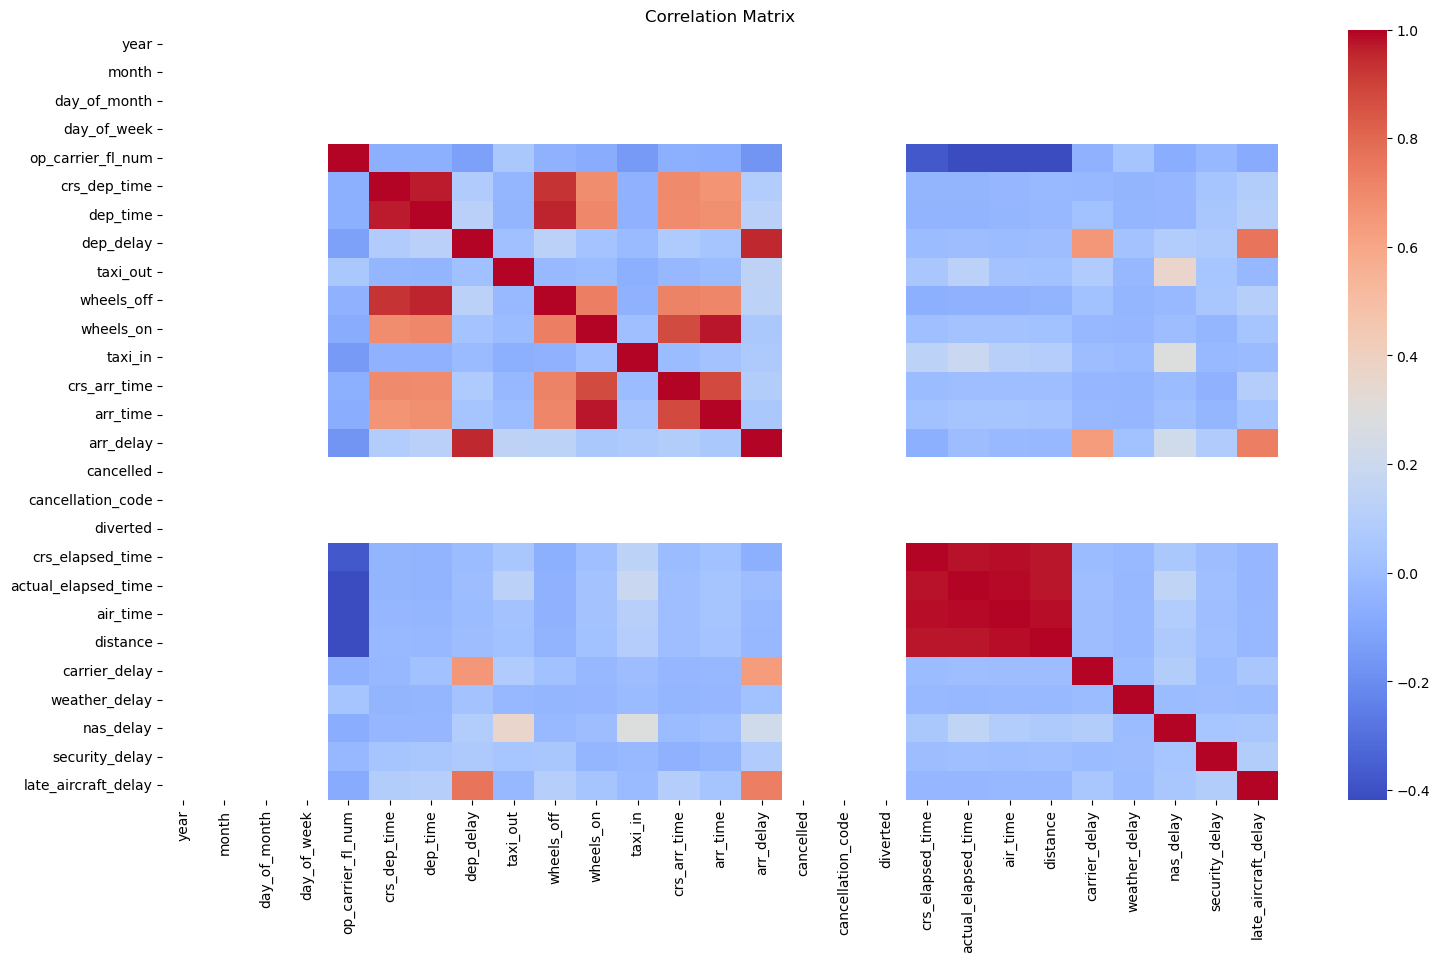

In [14]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(18,10))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

In [15]:
df['Delayed'] = np.where(df['dep_delay'] > 15, 1, 0)

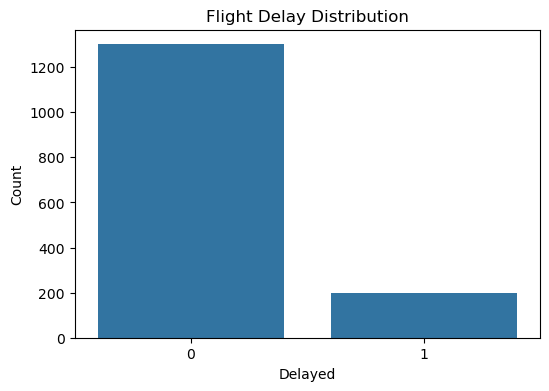

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Delayed'
)

plt.title("Flight Delay Distribution")

plt.xlabel("Delayed")

plt.ylabel("Count")

plt.show()

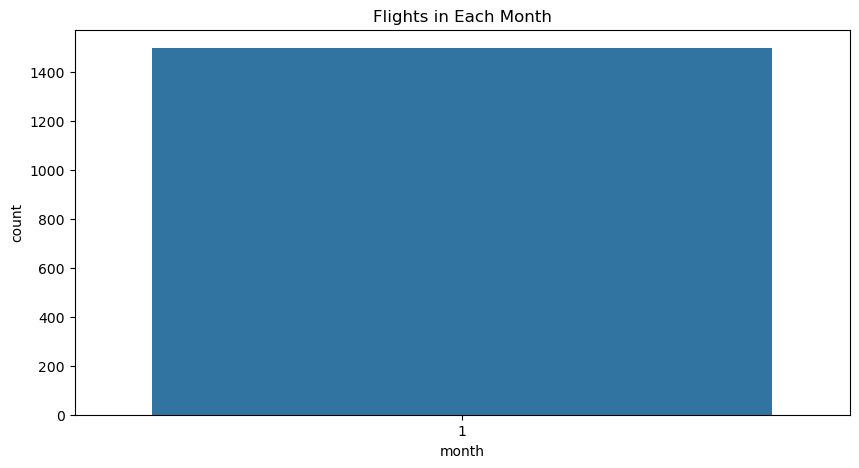

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='month'
)

plt.title("Flights in Each Month")

plt.show()

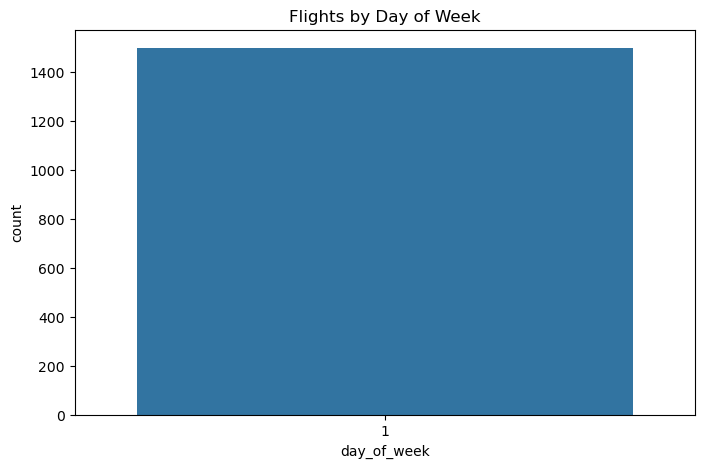

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='day_of_week'
)

plt.title("Flights by Day of Week")

plt.show()

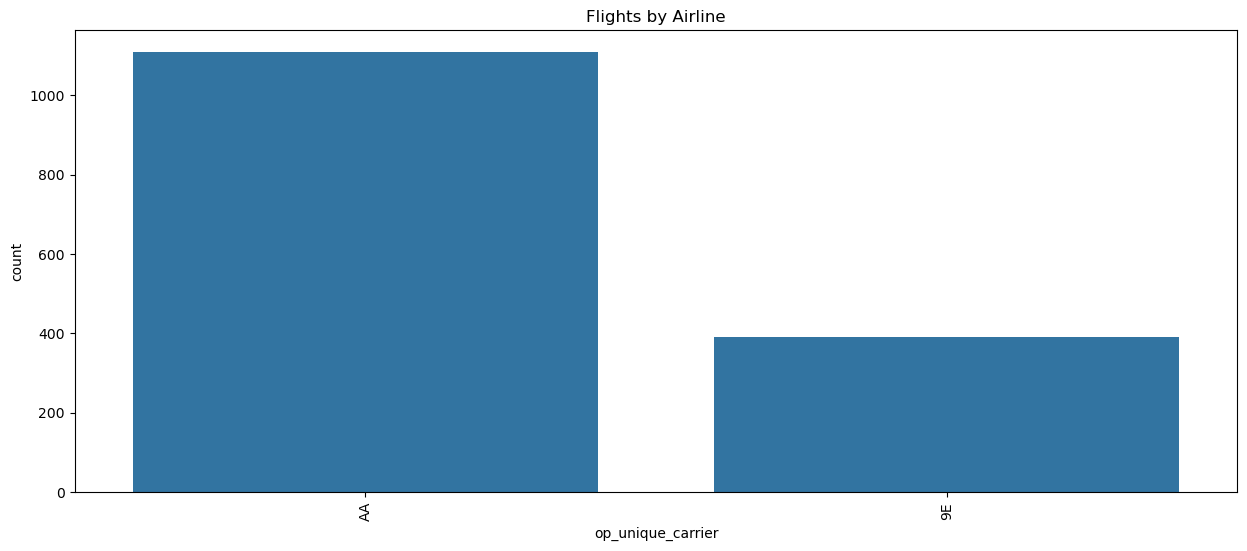

In [19]:
plt.figure(figsize=(15,6))

sns.countplot(
    data=df,
    x='op_unique_carrier',
    order=df['op_unique_carrier'].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Flights by Airline")

plt.show()

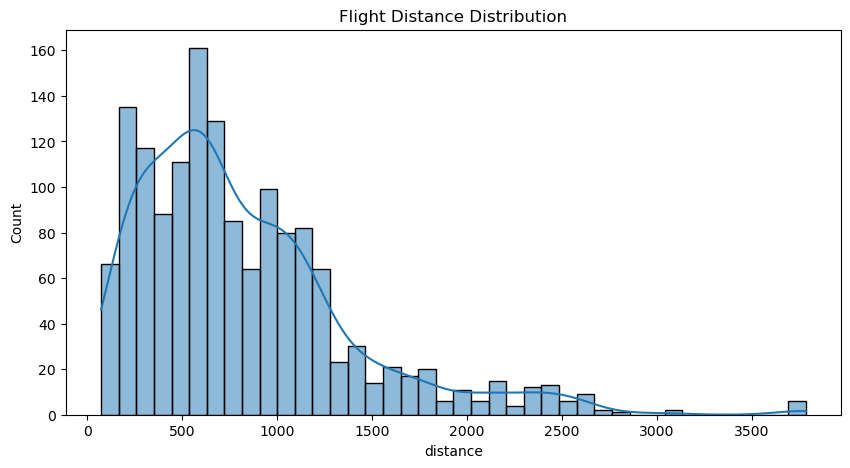

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['distance'],
    bins=40,
    kde=True
)

plt.title("Flight Distance Distribution")

plt.show()

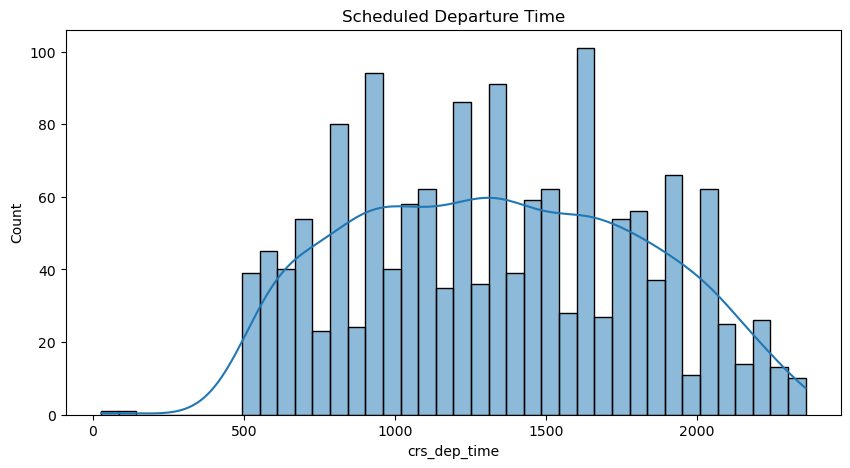

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['crs_dep_time'],
    bins=40,
    kde=True
)

plt.title("Scheduled Departure Time")

plt.show()

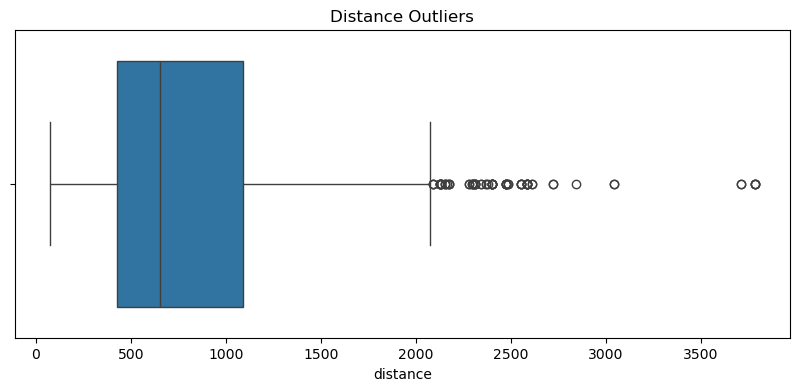

In [22]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['distance']
)

plt.title("Distance Outliers")

plt.show()

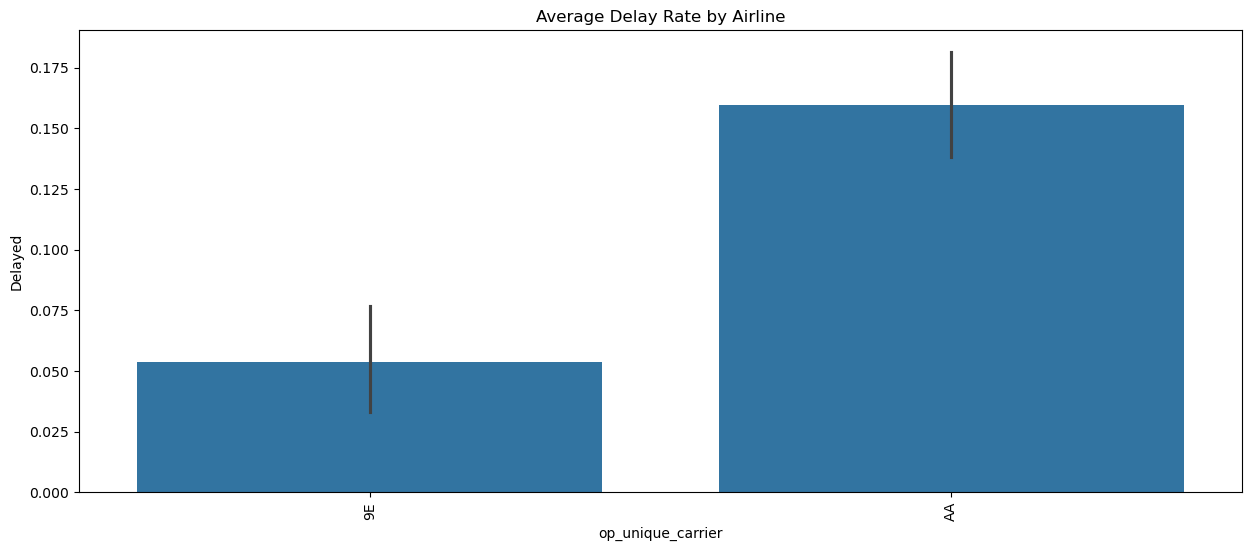

In [23]:
plt.figure(figsize=(15,6))

sns.barplot(
    data=df,
    x='op_unique_carrier',
    y='Delayed',
    estimator=np.mean
)

plt.xticks(rotation=90)

plt.title("Average Delay Rate by Airline")

plt.show()

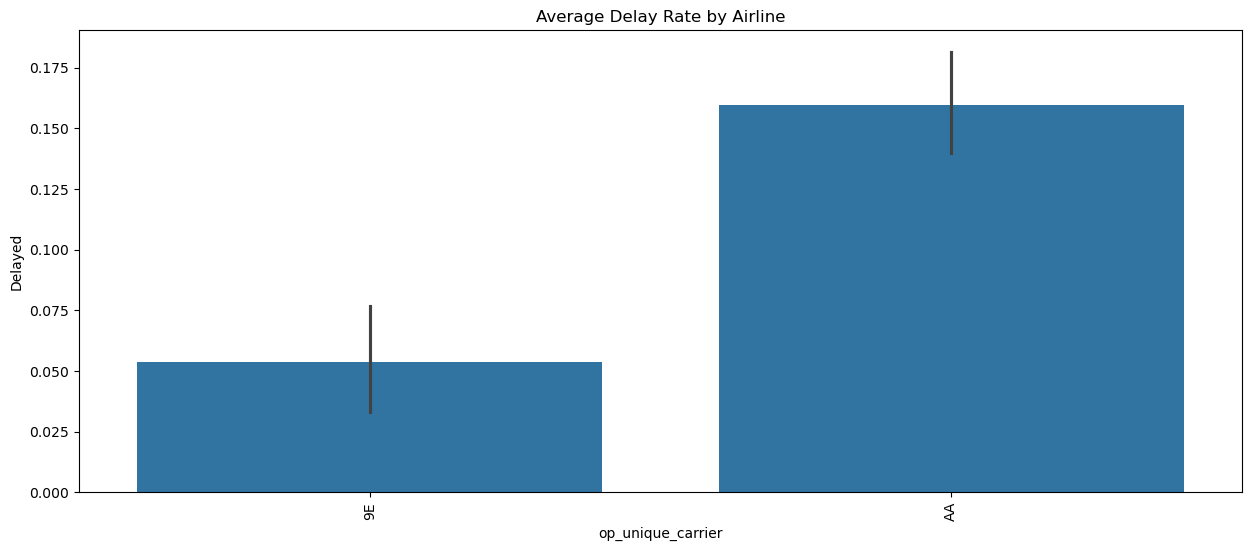

In [24]:
plt.figure(figsize=(15,6))

sns.barplot(
    data=df,
    x='op_unique_carrier',
    y='Delayed',
    estimator=np.mean
)

plt.xticks(rotation=90)

plt.title("Average Delay Rate by Airline")

plt.show()

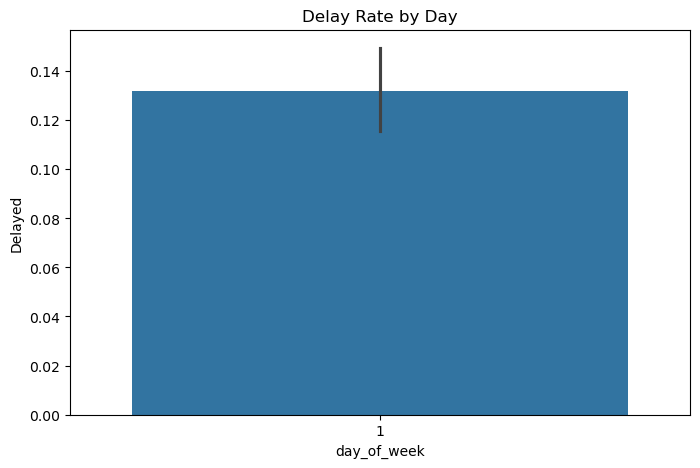

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='day_of_week',
    y='Delayed',
    estimator=np.mean
)

plt.title("Delay Rate by Day")

plt.show()

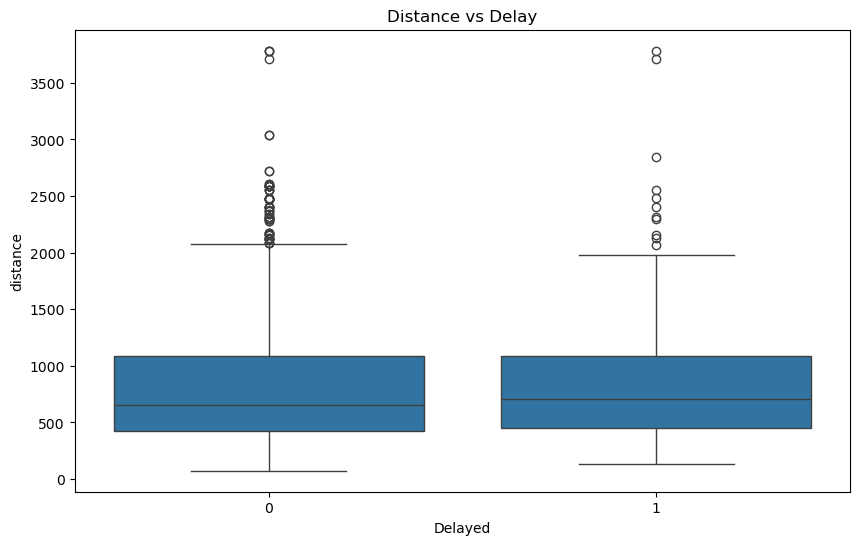

In [26]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Delayed',
    y='distance'
)

plt.title("Distance vs Delay")

plt.show()

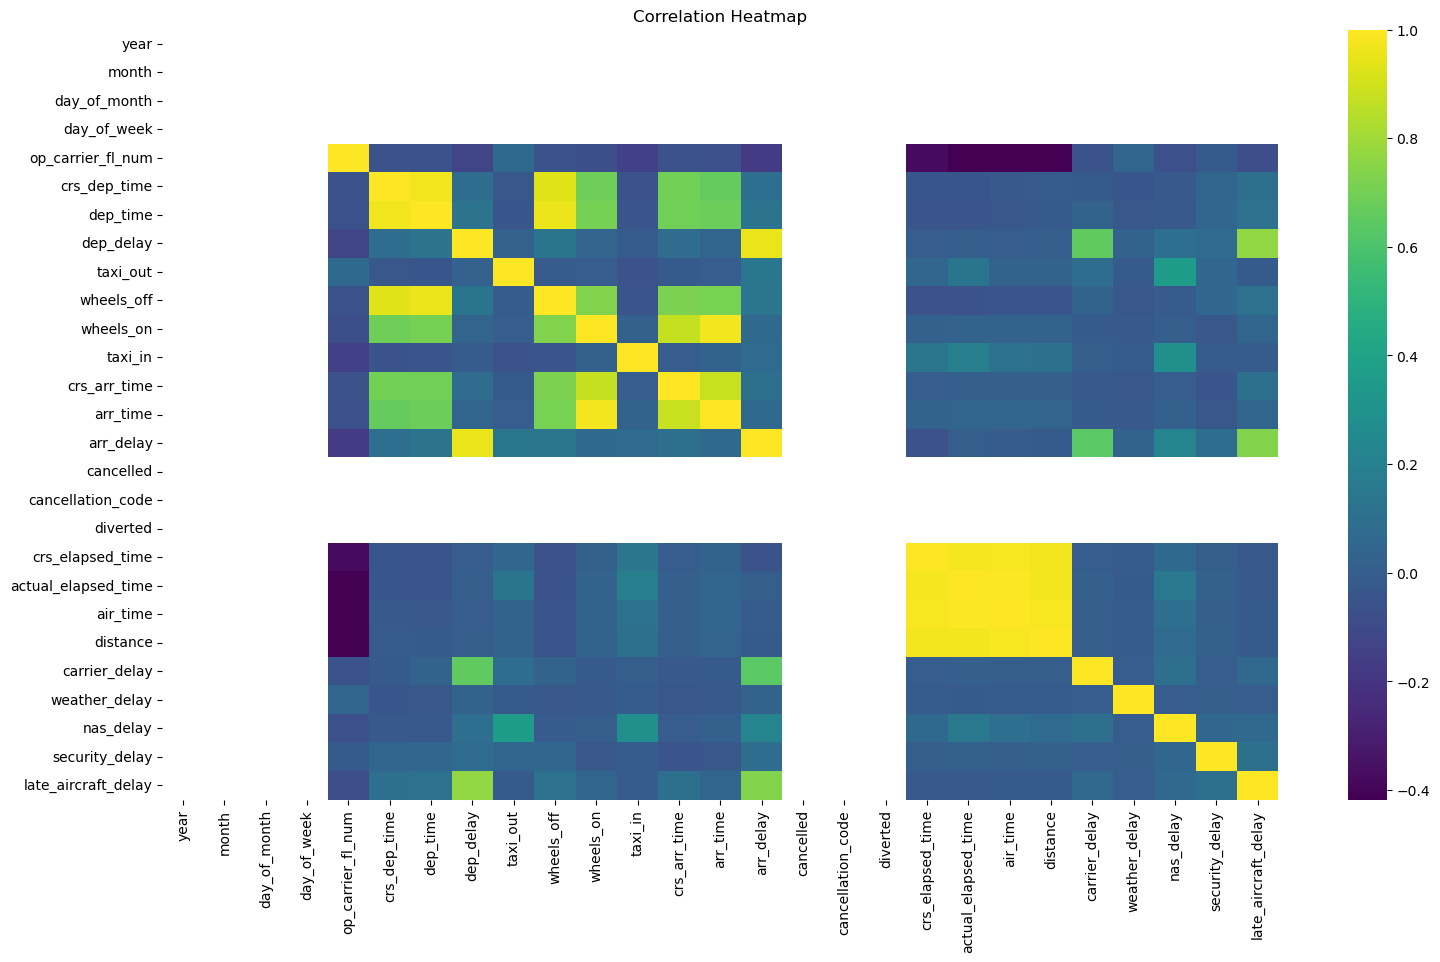

In [27]:
plt.figure(figsize=(18,10))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    cmap='viridis',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

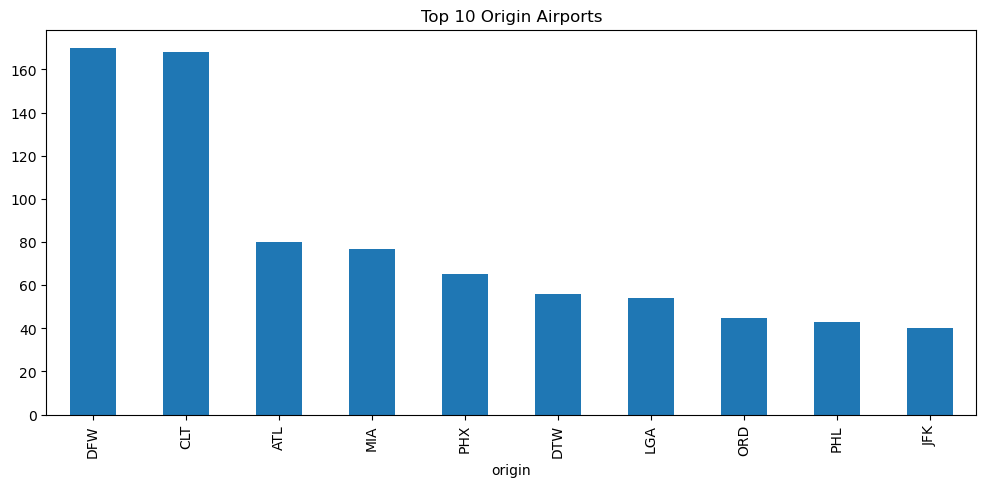

In [28]:
plt.figure(figsize=(12,5))

df['origin'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Origin Airports")

plt.show()

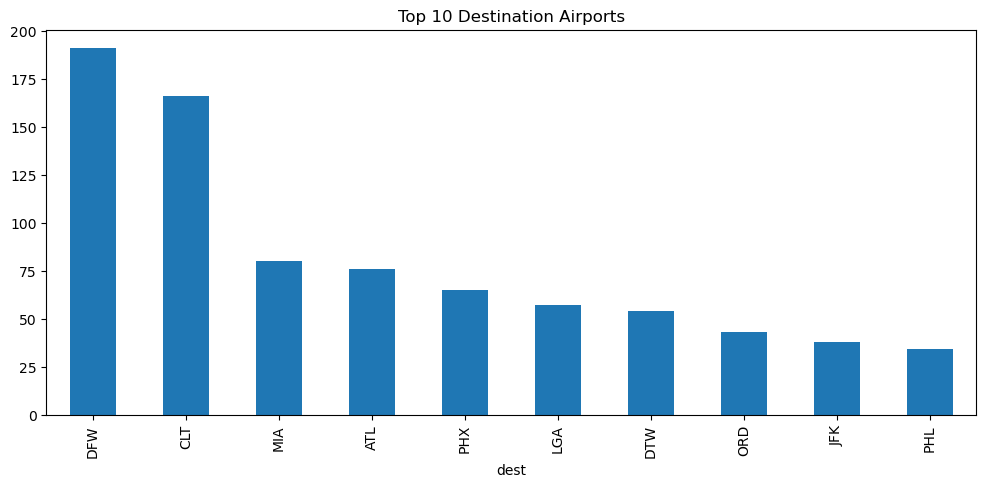

In [29]:
plt.figure(figsize=(12,5))

df['dest'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Destination Airports")

plt.show()

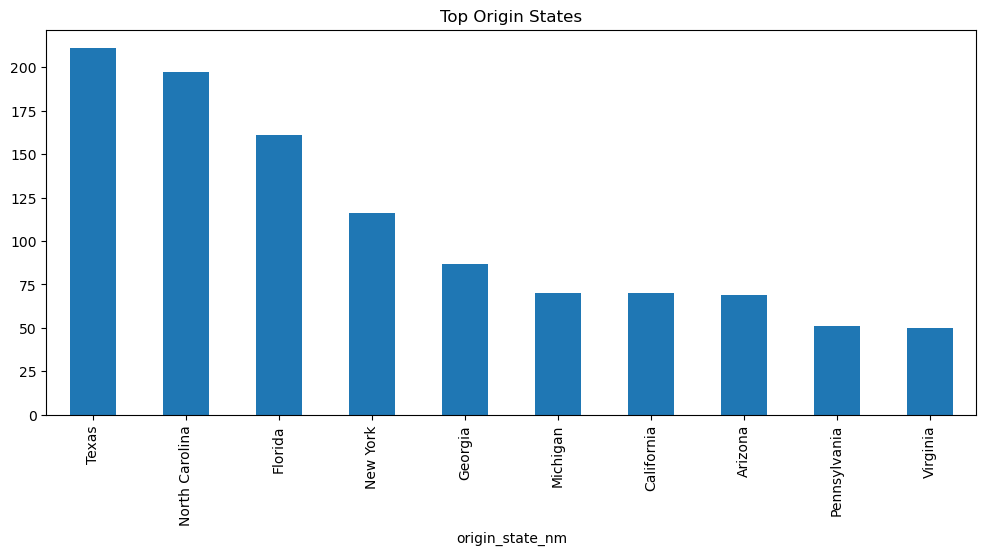

In [30]:
plt.figure(figsize=(12,5))

df['origin_state_nm'].value_counts().head(10).plot(kind='bar')

plt.title("Top Origin States")

plt.show()

After generating the plots, write observations based on your actual outputs rather than generic statements.

For example:

The target variable distribution indicates whether the dataset is balanced or imbalanced.
Flight traffic is concentrated in certain months, airlines, and airports.
Flight distances are right-skewed, with many short- and medium-haul flights.
Distance contains outliers, representing long-haul routes.
Some airlines have noticeably higher average delay rates than others.
Delay rates vary across months and days of the week, suggesting seasonal and operational effects.

Avoid writing conclusions that don't match your graphs.

In [31]:
# ============================================
# Create Working Copy
# ============================================

df_clean = df.copy()

# Remove duplicate records
df_clean.drop_duplicates(inplace=True)

# Create Target Variable
df_clean["Delayed"] = np.where(df_clean["dep_delay"] > 15, 1, 0)

# Remove leakage columns
leakage_columns = [
    "dep_delay",
    "arr_delay",
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay",
    "actual_elapsed_time",
    "air_time",
    "wheels_off",
    "wheels_on",
    "taxi_out",
    "taxi_in",
    "dep_time",
    "arr_time",
    "cancellation_code"
]

df_clean.drop(columns=leakage_columns, inplace=True, errors="ignore")

print(df_clean.shape)

(1499, 20)


In [32]:
missing = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Percentage": round(df_clean.isnull().mean()*100,2)
})

missing = missing[missing["Missing Values"] > 0]

missing.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage


In [33]:
duplicates = df_clean.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [34]:
df_clean.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (1499, 20)


In [35]:
df_clean.columns

Index(['year', 'month', 'day_of_month', 'day_of_week', 'fl_date',
       'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name',
       'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm',
       'crs_dep_time', 'crs_arr_time', 'cancelled', 'diverted',
       'crs_elapsed_time', 'distance', 'Delayed'],
      dtype='object')

In [36]:
df_clean['fl_date'] = pd.to_datetime(df_clean['fl_date'])

df_clean['flight_year'] = df_clean['fl_date'].dt.year
df_clean['flight_month'] = df_clean['fl_date'].dt.month
df_clean['flight_day'] = df_clean['fl_date'].dt.day
df_clean['flight_dayofweek'] = df_clean['fl_date'].dt.dayofweek
df_clean['flight_week'] = df_clean['fl_date'].dt.isocalendar().week.astype(int)

print("Date features created.")

Date features created.


In [37]:
df_clean.drop(columns=['fl_date'], inplace=True)

In [38]:
df_clean.isnull().sum().sort_values(ascending=False)

year                 0
month                0
flight_dayofweek     0
flight_day           0
flight_month         0
flight_year          0
Delayed              0
distance             0
crs_elapsed_time     0
diverted             0
cancelled            0
crs_arr_time         0
crs_dep_time         0
dest_state_nm        0
dest_city_name       0
dest                 0
origin_state_nm      0
origin_city_name     0
origin               0
op_carrier_fl_num    0
op_unique_carrier    0
day_of_week          0
day_of_month         0
flight_week          0
dtype: int64

In [39]:
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

In [40]:
cat_cols = df_clean.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

In [41]:
df_clean.isnull().sum().sum()

np.int64(0)

In [42]:
df_clean.head()

,year,month,day_of_month,day_of_week,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,...,cancelled,diverted,crs_elapsed_time,distance,Delayed,flight_year,flight_month,flight_day,flight_dayofweek,flight_week
0,2024,1,1,1,9E,4814,JFK,"New York, NY",New York,DTW,...,0,0,136,509,0,2024,1,1,0,1
1,2024,1,1,1,9E,4815,MSP,"Minneapolis, MN",Minnesota,CLE,...,0,0,130,622,0,2024,1,1,0,1
2,2024,1,1,1,9E,4817,JFK,"New York, NY",New York,RIC,...,0,0,106,288,0,2024,1,1,0,1
3,2024,1,1,1,9E,4817,RIC,"Richmond, VA",Virginia,JFK,...,0,0,111,288,0,2024,1,1,0,1
4,2024,1,1,1,9E,4818,DTW,"Detroit, MI",Michigan,MKE,...,0,0,79,237,0,2024,1,1,0,1


In [43]:
df_clean['departure_hour'] = (df_clean['crs_dep_time'] // 100).astype(int)

df_clean[['crs_dep_time', 'departure_hour']].head()

,crs_dep_time,departure_hour
0,1252,12
1,1015,10
2,1415,14
3,1650,16
4,1015,10


In [44]:
df_clean['arrival_hour'] = (df_clean['crs_arr_time'] // 100).astype(int)

df_clean[['crs_arr_time', 'arrival_hour']].head()

,crs_arr_time,arrival_hour
0,1508,15
1,1325,13
2,1601,16
3,1841,18
4,1034,10


In [45]:
def time_period(hour):

    if 5 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"

df_clean['departure_period'] = df_clean['departure_hour'].apply(time_period)

df_clean[['departure_hour', 'departure_period']].head()

,departure_hour,departure_period
0,12,Afternoon
1,10,Morning
2,14,Afternoon
3,16,Afternoon
4,10,Morning


In [46]:
df_clean['is_weekend'] = df_clean['day_of_week'].apply(
    lambda x: 1 if x in [6, 7] else 0
)

df_clean[['day_of_week', 'is_weekend']].head()

,day_of_week,is_weekend
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


In [47]:
df_clean['route'] = (
    df_clean['origin'] + "_" + df_clean['dest']
)

df_clean[['origin', 'dest', 'route']].head()

,origin,dest,route
0,JFK,DTW,JFK_DTW
1,MSP,CLE,MSP_CLE
2,JFK,RIC,JFK_RIC
3,RIC,JFK,RIC_JFK
4,DTW,MKE,DTW_MKE


In [48]:
df_clean['distance_category'] = pd.cut(
    df_clean['distance'],
    bins=[0, 500, 1500, np.inf],
    labels=['Short', 'Medium', 'Long']
)

df_clean[['distance', 'distance_category']].head()

,distance,distance_category
0,509,Medium
1,622,Medium
2,288,Short
3,288,Short
4,237,Short


In [49]:
df_clean['duration_category'] = pd.cut(
    df_clean['crs_elapsed_time'],
    bins=[0, 120, 240, np.inf],
    labels=['Short', 'Medium', 'Long']
)

df_clean[['crs_elapsed_time', 'duration_category']].head()

,crs_elapsed_time,duration_category
0,136,Medium
1,130,Medium
2,106,Short
3,111,Short
4,79,Short


In [50]:
new_features = [
    'departure_hour',
    'arrival_hour',
    'departure_period',
    'is_weekend',
    'route',
    'distance_category',
    'duration_category'
]

df_clean[new_features].head()

,departure_hour,arrival_hour,departure_period,is_weekend,route,distance_category,duration_category
0,12,15,Afternoon,0,JFK_DTW,Medium,Medium
1,10,13,Morning,0,MSP_CLE,Medium,Medium
2,14,16,Afternoon,0,JFK_RIC,Short,Short
3,16,18,Afternoon,0,RIC_JFK,Short,Short
4,10,10,Morning,0,DTW_MKE,Short,Short


In [51]:
# Remove Flight Number

df_clean.drop(
    columns=["op_carrier_fl_num"],
    inplace=True
)

In [52]:
# ============================================
# Save Dropdown Values
# ============================================

import joblib

dropdown_values = {

    "airlines": sorted(df_clean["op_unique_carrier"].unique()),

    "origins": sorted(df_clean["origin"].unique()),

    "origin_cities": sorted(df_clean["origin_city_name"].unique()),

    "origin_states": sorted(df_clean["origin_state_nm"].unique()),

    "destinations": sorted(df_clean["dest"].unique()),

    "destination_cities": sorted(df_clean["dest_city_name"].unique()),

    "destination_states": sorted(df_clean["dest_state_nm"].unique())

}

joblib.dump(dropdown_values, "dropdown_values.pkl")

print("Dropdown values saved successfully!")

Dropdown values saved successfully!


In [53]:
# ============================================
# Separate Features & Target
# ============================================

X = df_clean.drop("Delayed", axis=1)

y = df_clean["Delayed"]

print(X.shape)

print(y.shape)

(1499, 29)
(1499,)


In [54]:
from sklearn.preprocessing import LabelEncoder
import joblib

label_encoders = {}

label_columns = [
    "op_unique_carrier",
    "origin",
    "origin_city_name",
    "origin_state_nm",
    "dest",
    "dest_city_name",
    "dest_state_nm",
    "route"
]

# Fit on the entire dataset
for col in label_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

joblib.dump(label_encoders, "label_encoders.pkl")

print("Label Encoding Completed")

Label Encoding Completed


In [55]:
# ============================================
# One-Hot Encoding
# ============================================

one_hot_columns = [
    "departure_period",
    "distance_category",
    "duration_category"
]

X = pd.get_dummies(
    X,
    columns=one_hot_columns,
    drop_first=True
)

print("Shape after One-Hot Encoding:", X.shape)

Shape after One-Hot Encoding: (1499, 33)


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print(X_train.shape)
print(X_test.shape)

(1199, 33)
(300, 33)


In [57]:
import joblib

joblib.dump(
    X_train.columns.tolist(),
    "train_columns.pkl"
)

print("Training Columns Saved Successfully!")

Training Columns Saved Successfully!


In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed Successfully!")

Scaling Completed Successfully!


In [59]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler Saved Successfully!")

Scaler Saved Successfully!


In [60]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(
    X_train_scaled,
    y_train
)

print("Baseline KNN Model Trained Successfully!")

Baseline KNN Model Trained Successfully!


In [61]:
# Prediction

y_pred = knn.predict(X_test_scaled)

y_prob = knn.predict_proba(X_test_scaled)[:,1]

In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", round(accuracy_score(y_test,y_pred),4))
print("Precision :", round(precision_score(y_test,y_pred),4))
print("Recall :", round(recall_score(y_test,y_pred),4))
print("F1 Score :", round(f1_score(y_test,y_pred),4))
print("ROC AUC :", round(roc_auc_score(y_test,y_prob),4))

Accuracy : 0.84
Precision : 0.2143
Recall : 0.075
F1 Score : 0.1111
ROC AUC : 0.5428


In [63]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_neighbors": [3,5,7,9,11,13,15],
    "weights": ["uniform","distance"],
    "metric": ["euclidean","manhattan"]
}

random_search = RandomizedSearchCV(

    estimator=KNeighborsClassifier(),

    param_distributions=param_dist,

    n_iter=8,

    cv=3,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1,

    verbose=2

)

random_search.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,estimator,KNeighborsClassifier()
,param_distributions,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,n_iter,8
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [64]:
print("Best Parameters :")
print(random_search.best_params_)

print()

print("Best Cross Validation Score :")
print(round(random_search.best_score_,4))

Best Parameters :
{'weights': 'uniform', 'n_neighbors': 15, 'metric': 'euclidean'}

Best Cross Validation Score :
0.8682


In [65]:
best_knn = random_search.best_estimator_

In [66]:
y_pred_best = best_knn.predict(X_test_scaled)

y_prob_best = best_knn.predict_proba(X_test_scaled)[:,1]

In [67]:
print("Accuracy :", round(accuracy_score(y_test,y_pred_best),4))
print("Precision :", round(precision_score(y_test,y_pred_best),4))
print("Recall :", round(recall_score(y_test,y_pred_best),4))
print("F1 Score :", round(f1_score(y_test,y_pred_best),4))
print("ROC AUC :", round(roc_auc_score(y_test,y_prob_best),4))

Accuracy : 0.8667
Precision : 0.0
Recall : 0.0
F1 Score : 0.0
ROC AUC : 0.6009


In [68]:
joblib.dump(

    best_knn,

    "flight_delay_model.pkl"

)

print("Model Saved Successfully.")

Model Saved Successfully.


In [69]:
import joblib

dropdown_values = {
    "airlines": sorted(df_clean["op_unique_carrier"].dropna().unique().tolist()),
    "origins": sorted(df_clean["origin"].dropna().unique().tolist()),
    "origin_cities": sorted(df_clean["origin_city_name"].dropna().unique().tolist()),
    "origin_states": sorted(df_clean["origin_state_nm"].dropna().unique().tolist()),
    "destinations": sorted(df_clean["dest"].dropna().unique().tolist()),
    "destination_cities": sorted(df_clean["dest_city_name"].dropna().unique().tolist()),
    "destination_states": sorted(df_clean["dest_state_nm"].dropna().unique().tolist())
}

joblib.dump(dropdown_values, "dropdown_values.pkl")

print("Dropdown values saved successfully!")

Dropdown values saved successfully!


In [70]:
import os

files = [

    "flight_delay_model.pkl",

    "scaler.pkl",

    "label_encoders.pkl",

    "train_columns.pkl",

    "dropdown_values.pkl"

]

for file in files:

    print(file, ":", os.path.exists(file))

flight_delay_model.pkl : True
scaler.pkl : True
label_encoders.pkl : True
train_columns.pkl : True
dropdown_values.pkl : True


In [71]:
print(X_train.columns.tolist())

['year', 'month', 'day_of_month', 'day_of_week', 'op_unique_carrier', 'origin', 'origin_city_name', 'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm', 'crs_dep_time', 'crs_arr_time', 'cancelled', 'diverted', 'crs_elapsed_time', 'distance', 'flight_year', 'flight_month', 'flight_day', 'flight_dayofweek', 'flight_week', 'departure_hour', 'arrival_hour', 'is_weekend', 'route', 'departure_period_Evening', 'departure_period_Morning', 'departure_period_Night', 'distance_category_Medium', 'distance_category_Long', 'duration_category_Medium', 'duration_category_Long']


In [72]:
import joblib

train_columns = joblib.load("train_columns.pkl")

print(train_columns)

['year', 'month', 'day_of_month', 'day_of_week', 'op_unique_carrier', 'origin', 'origin_city_name', 'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm', 'crs_dep_time', 'crs_arr_time', 'cancelled', 'diverted', 'crs_elapsed_time', 'distance', 'flight_year', 'flight_month', 'flight_day', 'flight_dayofweek', 'flight_week', 'departure_hour', 'arrival_hour', 'is_weekend', 'route', 'departure_period_Evening', 'departure_period_Morning', 'departure_period_Night', 'distance_category_Medium', 'distance_category_Long', 'duration_category_Medium', 'duration_category_Long']


In [73]:
import joblib

encoders = joblib.load("label_encoders.pkl")

print(len(encoders["route"].classes_))
print(encoders["route"].classes_[:20])   # First 20 routes

809
['ABE_ATL' 'ABQ_DFW' 'ABQ_ORD' 'AEX_ATL' 'AGS_ATL' 'ALB_CLT' 'ALB_LGA'
 'AMA_DFW' 'ANC_DFW' 'ATL_ABE' 'ATL_AEX' 'ATL_AGS' 'ATL_ATW' 'ATL_AVL'
 'ATL_BMI' 'ATL_BTR' 'ATL_CHA' 'ATL_CHO' 'ATL_CLT' 'ATL_CRW']


In [74]:
print(encoders["route"].classes_[-20:])  # Last 20 routes

['SYR_DTW' 'SYR_JFK' 'TLH_ATL' 'TPA_CLT' 'TPA_DCA' 'TPA_DFW' 'TPA_MIA'
 'TPA_PHX' 'TRI_ATL' 'TUL_ATL' 'TUL_CLT' 'TUL_DFW' 'TUS_DFW' 'TUS_ORD'
 'TUS_PHX' 'TYS_ATL' 'TYS_DTW' 'TYS_LGA' 'VLD_ATL' 'XNA_ATL']


In [75]:
df_clean[["origin","dest"]].drop_duplicates().head(20)

,origin,dest
0,JFK,DTW
1,MSP,CLE
2,JFK,RIC
3,RIC,JFK
4,DTW,MKE
5,JAX,LGA
6,LGA,JAX
7,CHS,LGA
8,LGA,CHS
9,ITH,JFK


In [76]:
print("ATL_TLH" in encoders["route"].classes_)
print("TLH_ATL" in encoders["route"].classes_)
print("JFK_DTW" in encoders["route"].classes_)

True
True
True
